## Импорты и настройки

In [37]:
import numpy as np
import random 
import matplotlib.pyplot as plt
import os
import time
import glob
import torch
import torch.nn as nn
import torchvision
from torchvision import models
from torch.utils.data import Dataset, DataLoader
import cv2

%matplotlib inline

In [38]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Устройство для обучения: {device}")

Устройство для обучения: cpu


## Пути и преобразования

In [39]:
DATA_DIR = r"C:\Users\aleks\Documents\data"

TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR = os.path.join(DATA_DIR, "valid")

In [40]:
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## Загрузка данных через DataLoader

In [41]:
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=val_transform)

class_names = train_dataset.classes
num_classes = len(class_names)

print(f"Классы: {class_names}")
print(f"Количество классов: {num_classes}")
print(f"Размер train-выборки: {len(train_dataset)}")
print(f"Размер validation-выборки: {len(val_dataset)}")

Классы: ['bill_gates', 'elon_musk', 'jeff_bezos', 'mark_zuckerberg', 'steve_jobs']
Количество классов: 5
Размер train-выборки: 3000
Размер validation-выборки: 914


In [42]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print(f"Батчей в train: {len(train_loader)}")
print(f"Батчей в validation: {len(val_loader)}")

Батчей в train: 94
Батчей в validation: 29


## Визуализация одного батча

In [43]:
def denormalize(image):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    image = image.cpu() * std + mean
    return torch.clamp(image, 0, 1)

In [44]:
def show_batch(loader, class_names, n_images=12):
    images, labels = next(iter(loader))

    n_images = min(n_images, len(images))
    cols = 4
    rows = int(np.ceil(n_images / cols))

    plt.figure(figsize=(14, 3 * rows))

    for i in range(n_images):
        plt.subplot(rows, cols, i + 1)
        image = denormalize(images[i]).permute(1, 2, 0)

        plt.imshow(image)
        plt.title(class_names[labels[i].item()])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

## Предобученная модель

In [45]:
weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)

for param in model.parameters():
    param.requires_grad = False

in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)

model = model.to(device)

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

## Функция обучения

In [46]:
import torch.optim as optim
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)

In [47]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    best_model_weights = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0

    for epoch in range(epochs):
        #  Обучение 
        model.train()

        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)
            train_correct += (predictions == labels).sum().item()
            train_total += labels.size(0)

        epoch_train_loss = train_loss / train_total
        epoch_train_acc = train_correct / train_total

        # Валидация
        model.eval()

        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)

                predictions = outputs.argmax(dim=1)
                val_correct += (predictions == labels).sum().item()
                val_total += labels.size(0)

        epoch_val_loss = val_loss / val_total
        epoch_val_acc = val_correct / val_total

        history["train_loss"].append(epoch_train_loss)
        history["train_acc"].append(epoch_train_acc)
        history["val_loss"].append(epoch_val_loss)
        history["val_acc"].append(epoch_val_acc)

        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            best_model_weights = copy.deepcopy(model.state_dict())

        print(
            f"Epoch {epoch + 1:02d}/{epochs} | "
            f"train_loss: {epoch_train_loss:.4f} | "
            f"train_acc: {epoch_train_acc:.4f} | "
            f"val_loss: {epoch_val_loss:.4f} | "
            f"val_acc: {epoch_val_acc:.4f}"
        )

    # Восстанавливаем модель с лучшим результатом на validation.
    model.load_state_dict(best_model_weights)

    return model, history, best_val_acc

## Запуск обучения

In [48]:
EPOCHS = 10
import copy
model, history, best_val_acc = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=EPOCHS
)

print(f"\nЛучшая accuracy на validation: {best_val_acc:.4f}")

Epoch 01/10 | train_loss: 1.1123 | train_acc: 0.6080 | val_loss: 0.7797 | val_acc: 0.7757
Epoch 02/10 | train_loss: 0.7059 | train_acc: 0.7883 | val_loss: 0.6573 | val_acc: 0.7921
Epoch 03/10 | train_loss: 0.5813 | train_acc: 0.8237 | val_loss: 0.5075 | val_acc: 0.8457
Epoch 04/10 | train_loss: 0.5264 | train_acc: 0.8287 | val_loss: 0.5251 | val_acc: 0.8249
Epoch 05/10 | train_loss: 0.4849 | train_acc: 0.8433 | val_loss: 0.4750 | val_acc: 0.8381
Epoch 06/10 | train_loss: 0.4439 | train_acc: 0.8580 | val_loss: 0.4101 | val_acc: 0.8676
Epoch 07/10 | train_loss: 0.4246 | train_acc: 0.8650 | val_loss: 0.4337 | val_acc: 0.8512
Epoch 08/10 | train_loss: 0.3964 | train_acc: 0.8727 | val_loss: 0.3808 | val_acc: 0.8687
Epoch 09/10 | train_loss: 0.3975 | train_acc: 0.8633 | val_loss: 0.3467 | val_acc: 0.8807
Epoch 10/10 | train_loss: 0.3794 | train_acc: 0.8767 | val_loss: 0.3545 | val_acc: 0.8775

Лучшая accuracy на validation: 0.8807


## Графики обучения

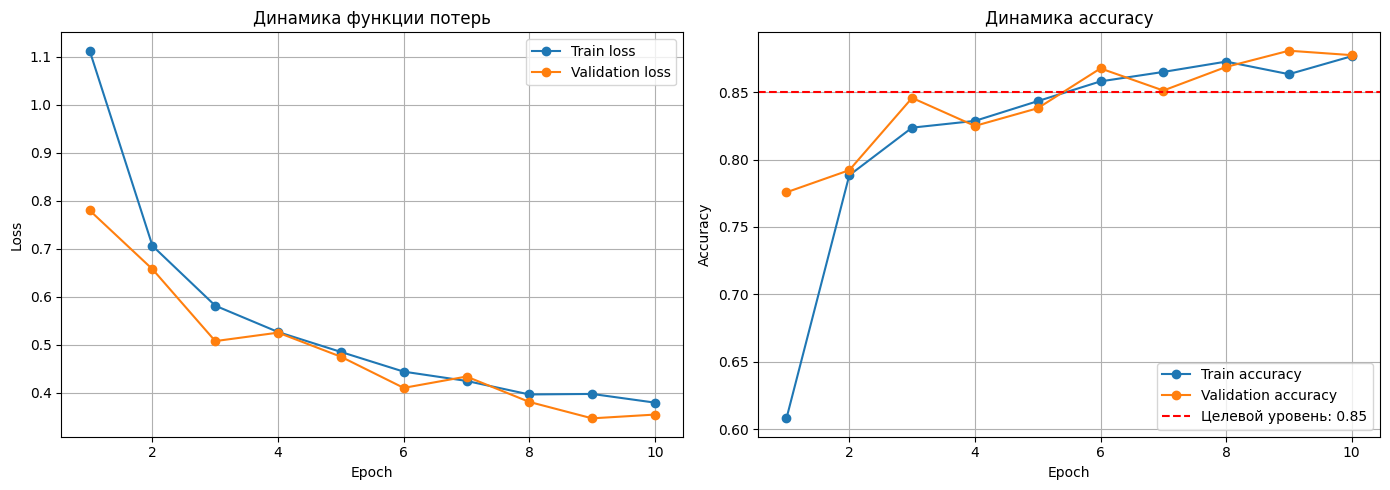

In [49]:
epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], marker="o", label="Train loss")
plt.plot(epochs_range, history["val_loss"], marker="o", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Динамика функции потерь")
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_acc"], marker="o", label="Train accuracy")
plt.plot(epochs_range, history["val_acc"], marker="o", label="Validation accuracy")
plt.axhline(0.85, color="red", linestyle="--", label="Целевой уровень: 0.85")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Динамика accuracy")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

## Визуализация предсказаний

In [50]:
def visualize_predictions(model, loader, class_names, n_images=12):
    model.eval()

    all_images = []
    all_labels = []
    all_predictions = []
    all_confidences = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            probabilities = torch.softmax(outputs, dim=1)
            confidences, predictions = torch.max(probabilities, dim=1)

            all_images.append(images.cpu())
            all_labels.append(labels.cpu())
            all_predictions.append(predictions.cpu())
            all_confidences.append(confidences.cpu())

    all_images = torch.cat(all_images)
    all_labels = torch.cat(all_labels)
    all_predictions = torch.cat(all_predictions)
    all_confidences = torch.cat(all_confidences)

    # Случайно выбираем изображения из всей validation-выборки
    indices = torch.randperm(len(all_images))[:n_images]

    cols = 4
    rows = int(np.ceil(n_images / cols))

    plt.figure(figsize=(16, 4 * rows))

    for position, idx in enumerate(indices):
        plt.subplot(rows, cols, position + 1)

        image = denormalize(all_images[idx]).permute(1, 2, 0)

        true_label = class_names[all_labels[idx].item()]
        pred_label = class_names[all_predictions[idx].item()]
        confidence = all_confidences[idx].item()

        color = "green" if all_predictions[idx] == all_labels[idx] else "red"

        plt.imshow(image)
        plt.title(
            f"Истина: {true_label.replace('_', ' ').title()}\n"
            f"Прогноз: {pred_label.replace('_', ' ').title()} ({confidence:.1%})",
            color=color
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

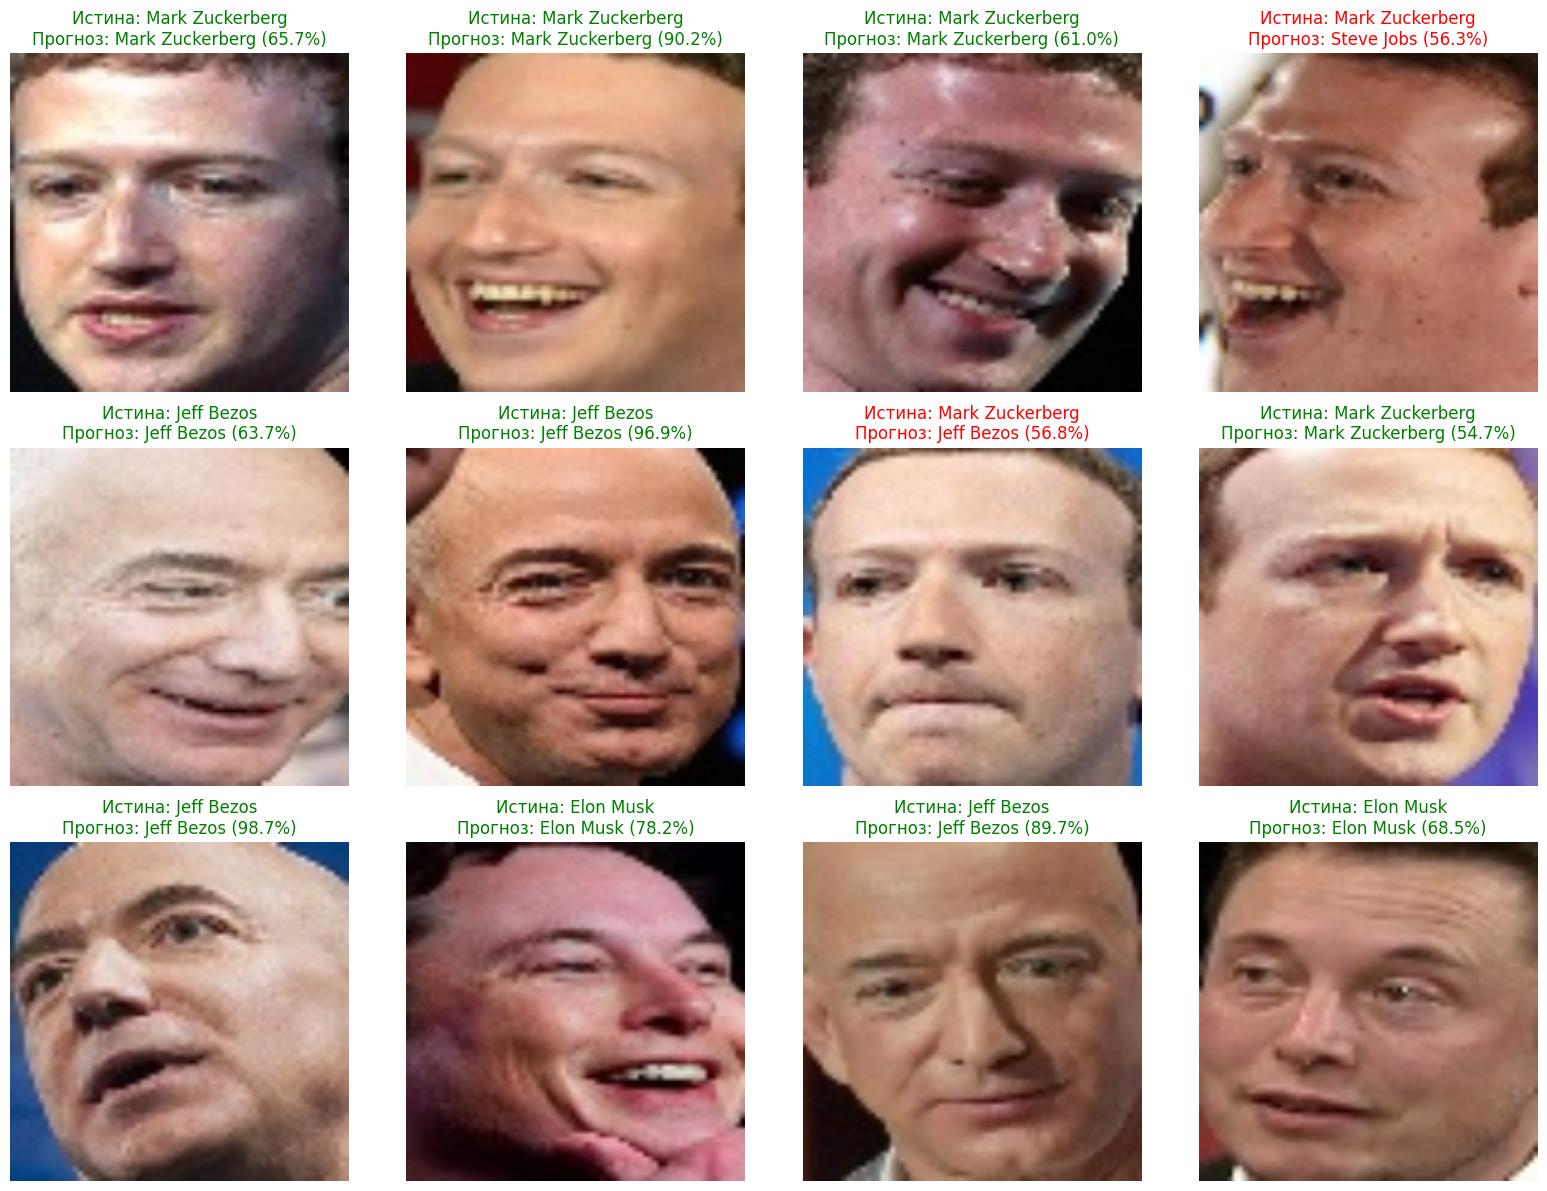

In [51]:
visualize_predictions(model, val_loader, class_names, n_images=12)

## Выводы

В работе была решена задача многоклассовой классификации изображений лиц пяти известных людей: Bill Gates, Elon Musk, Jeff Bezos, Mark Zuckerberg и Steve Jobs.

Данные были загружены с помощью `ImageFolder` и `DataLoader`. Обучающая выборка содержала 3000 изображений, а валидационная — 914 изображений. Число классов составило 5.

Для решения задачи был использован перенос обучения. В качестве базовой модели выбрана предобученная `ResNet18` с весами ImageNet. Все параметры исходной сети были заморожены, а последний полносвязный слой `fc` заменён на новый классификатор с 5 выходами — по числу классов датасета.

Модель обучалась 10 эпох на обучающей выборке. В процессе обучения использовались функция потерь `CrossEntropyLoss` и оптимизатор `Adam` с learning rate 0.001.

Лучшая accuracy на валидационной выборке составила **0.88** или **88%**. Это превышает требуемый порог 0.85, поэтому модель успешно справилась с поставленной задачей.

Визуализация предсказаний показывает, что модель корректно классифицирует большую часть изображений. Возможные ошибки связаны с похожими ракурсами, освещением, качеством фотографий, возрастными изменениями людей и визуальным сходством отдельных лиц на некоторых изображениях.